# AGN Emission Gallery

_agn_gallery

Comprehensive visual tour of every AGN emission component in tengri.

**Paper §3:** AGN adds hot continuum and lines in the forward composition (alongside nebular),
before dust attenuation and observation.

## What tengri has that other SED codes don't

| Capability | tengri | CIGALE | Prospector | Bagpipes |
|---|:---:|:---:|:---:|:---:|
| AGN emission lines (BLR + NLR) | **YES** | No | No | No |
| BH physics (M_BH, spin, L/L_Edd) | **YES** | No | No | No |
| Differentiable (gradient-based inference) | **YES** | No | No | No |
| Unified Type 1/2 geometric model | **YES** | Yes | No | No |
| Free parameter count (minimum) | 2–12 | 7 | 2 | — |
| AGN model exists at all | **YES** | Yes | Yes | **No** |

Bagpipes has no AGN model (Carnall+2018). Prospector uses 2 params with no
emission lines (Leja+2018). Only tengri constrains BH mass, spin, and AGN
line ratios jointly with the galaxy SED, fully differentiably.

## Model Registry

| Name | Disc | Torus | Params | Use |
|------|------|-------|--------|-----|
| `powerlaw_disc` | Power law | None | 2 | Quick test |
| `multicolor_disc` | SS73 multicolor | None | 4 | Standard Type 1 |
| `kubota_done_full` | K&D 3-zone | None | 9 | BH physics |
| `simple_torus` | None | 1-T MBB | 3 | Toy |
| `two_temperature_torus` | None | 2-T MBB | 5 | Better toy torus |
| `skirtor_analytic` | SS73 | SKIRTOR clumpy | 6 | **Recommended torus** |
| `unified_nlr_blr` | K&D + SKIRTOR | Yes + lines | 12 | Full unified model |
| `qsogen` | Temple+2021 | Implicit | 5 | Type 1 quasar template |

BLR/NLR line strengths calibrated to Vanden Berk+2001 composite.
Fe II pseudo-continuum: `agn_fe2_strength` (default 0, disabled).

In [ ]:
import importlib.util
import os
import sys
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import Fixed, SEDModel, Parameters, Uniform, load_ssp_data
from tengri.models.agn import (
    AGN_MODELS,
    adaf_agn,
    adaf_disc,
    blr_emission,
    get_agn_model,
    kubota_done_disc,
    kubota_done_full_agn,
    multicolor_disc,
    nlr_emission,
    powerlaw_disc,
    qsogen,
    qsogen_sed,
    simple_torus,
    two_temperature_torus,
    unified_nlr_blr,
)
from tengri.models.agn.disc import _isco_radius

try:
    from tengri.models.agn import unified_agn
except ImportError:
    unified_agn = unified_nlr_blr

_nbooks = os.path.join(_repo_root, "notebooks")
if os.path.isdir(_nbooks):
    sys.path.insert(0, _nbooks)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

try:
    from _plot_style import COLORS, setup_style
except ModuleNotFoundError:
    from tengri.plotting import setup_style

    COLORS = {
        "rt": "C0",
        "geovi": "C1",
        "nuts": "C2",
        "model": "C3",
        "seq": ["C0", "C1", "C2", "C3", "C4"],
    }

setup_style()

FIGDIR = os.path.join("notebooks", "figures", "agn_gallery")
os.makedirs(FIGDIR, exist_ok=True)


def _set_reasonable_log_ylim_from_axes(
    axes,
    pad_log=0.12,
    min_xy_points=4,
    floor_below_peak_dex=10.0,
    wide_log_span_threshold=10.0,
    percentile_lo_hi=(5.0, 95.0),
):
    """Tighten log *y* limits from line data inside each subplot's *x* range.

    - Skips ``axvline`` polylines (too few points or zero *x* span) so their
      artificial *y* range does not dominate limits.
    - Per line, drops values more than ``floor_below_peak_dex`` below that
      line's 99th percentile (removes line-model numerical floors / spikes).
    - If the pooled log-span still exceeds ``wide_log_span_threshold``, uses
      ``percentile_lo_hi`` on log10(y) instead of raw min/max.
    """
    ax_list = np.ravel(np.atleast_1d(axes))
    if ax_list.size == 0:
        return
    ys = []
    for ax in ax_list:
        x_lo, x_hi = ax.get_xlim()
        if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_lo >= x_hi:
            continue
        for line in ax.get_lines():
            x = np.asarray(line.get_xdata(), dtype=float)
            y = np.asarray(line.get_ydata(), dtype=float)
            if x.size < min_xy_points:
                continue
            x_span = float(np.ptp(x))
            x_scale = max(float(np.max(np.abs(x))), 1.0)
            if x_span <= 1e-9 * x_scale or x_span <= 1e-12:
                continue
            m = (x >= x_lo) & (x <= x_hi) & np.isfinite(y) & (y > 0)
            if not np.any(m):
                continue
            y_win = y[m]
            peak = float(np.percentile(y_win, 99.0))
            if not np.isfinite(peak) or peak <= 0:
                continue
            floor = peak * 10 ** (-floor_below_peak_dex)
            y_win = y_win[y_win >= floor]
            if y_win.size == 0:
                continue
            ys.append(y_win)
    if not ys:
        return
    y = np.concatenate(ys)
    logy = np.log10(y)
    if not np.all(np.isfinite(logy)):
        return
    raw_lo = float(np.min(logy))
    raw_hi = float(np.max(logy))
    if raw_hi - raw_lo > wide_log_span_threshold:
        p_lo, p_hi = percentile_lo_hi
        lo_log, hi_log = (float(t) for t in np.percentile(logy, [p_lo, p_hi]))
    else:
        lo_log, hi_log = raw_lo, raw_hi
    lo_log -= pad_log
    hi_log += pad_log
    if hi_log - lo_log < pad_log * 2:
        mid = 0.5 * (lo_log + hi_log)
        lo_log, hi_log = mid - pad_log * 2, mid + pad_log * 2
    y0, y1 = 10**lo_log, 10**hi_log
    if not np.isfinite(y0) or not np.isfinite(y1) or y0 <= 0 or y1 <= y0:
        return
    for ax in ax_list:
        ax.set_ylim(y0, y1)


# Physical constants
_LSUN_ERG = 3.828e33  # Solar luminosity [erg s^-1]

# Common wavelength grids
wavelength = jnp.logspace(np.log10(100), np.log10(1e6), 1000)
wave_um = np.asarray(wavelength) / 1e4
nu_arr = np.asarray(3e18 / wavelength)

# Extended grid for X-ray models
wave_xray = jnp.logspace(0.0, 6.0, 2000)  # 1 A to 1 mm
wave_xray_um = np.asarray(wave_xray) / 1e4
nu_xray = np.asarray(3e18 / wave_xray)

## 1. Overview: Full AGN SED (Disc + Torus + BLR + NLR)

A complete unified AGN SED spans from X-ray to far-infrared. The four main
components are:

1. **Accretion disc** (UV/optical): thermal emission from the accretion flow
2. **Dust torus** (MIR): re-processed disc emission absorbed and re-emitted by dust
3. **Broad Line Region** (UV/optical lines): dense gas close to the BH, FWHM ~5000 km/s
4. **Narrow Line Region** (optical lines): extended gas, FWHM ~500 km/s, isotropic

W0405 14:39:51.430382  154384 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_25235/674413394.py:48: DeprecationWarning: two_temperature_torus is a toy model (two-temperature MBB, not radiative transfer) and should NOT be used for science. Use skirtor_analytic from tengri.models.agn.skirtor for production work.
  agn_torus = np.asarray(two_temperature_torus(wavelength, agn_log_lbol=45.5, agn_torus_frac=0.3))


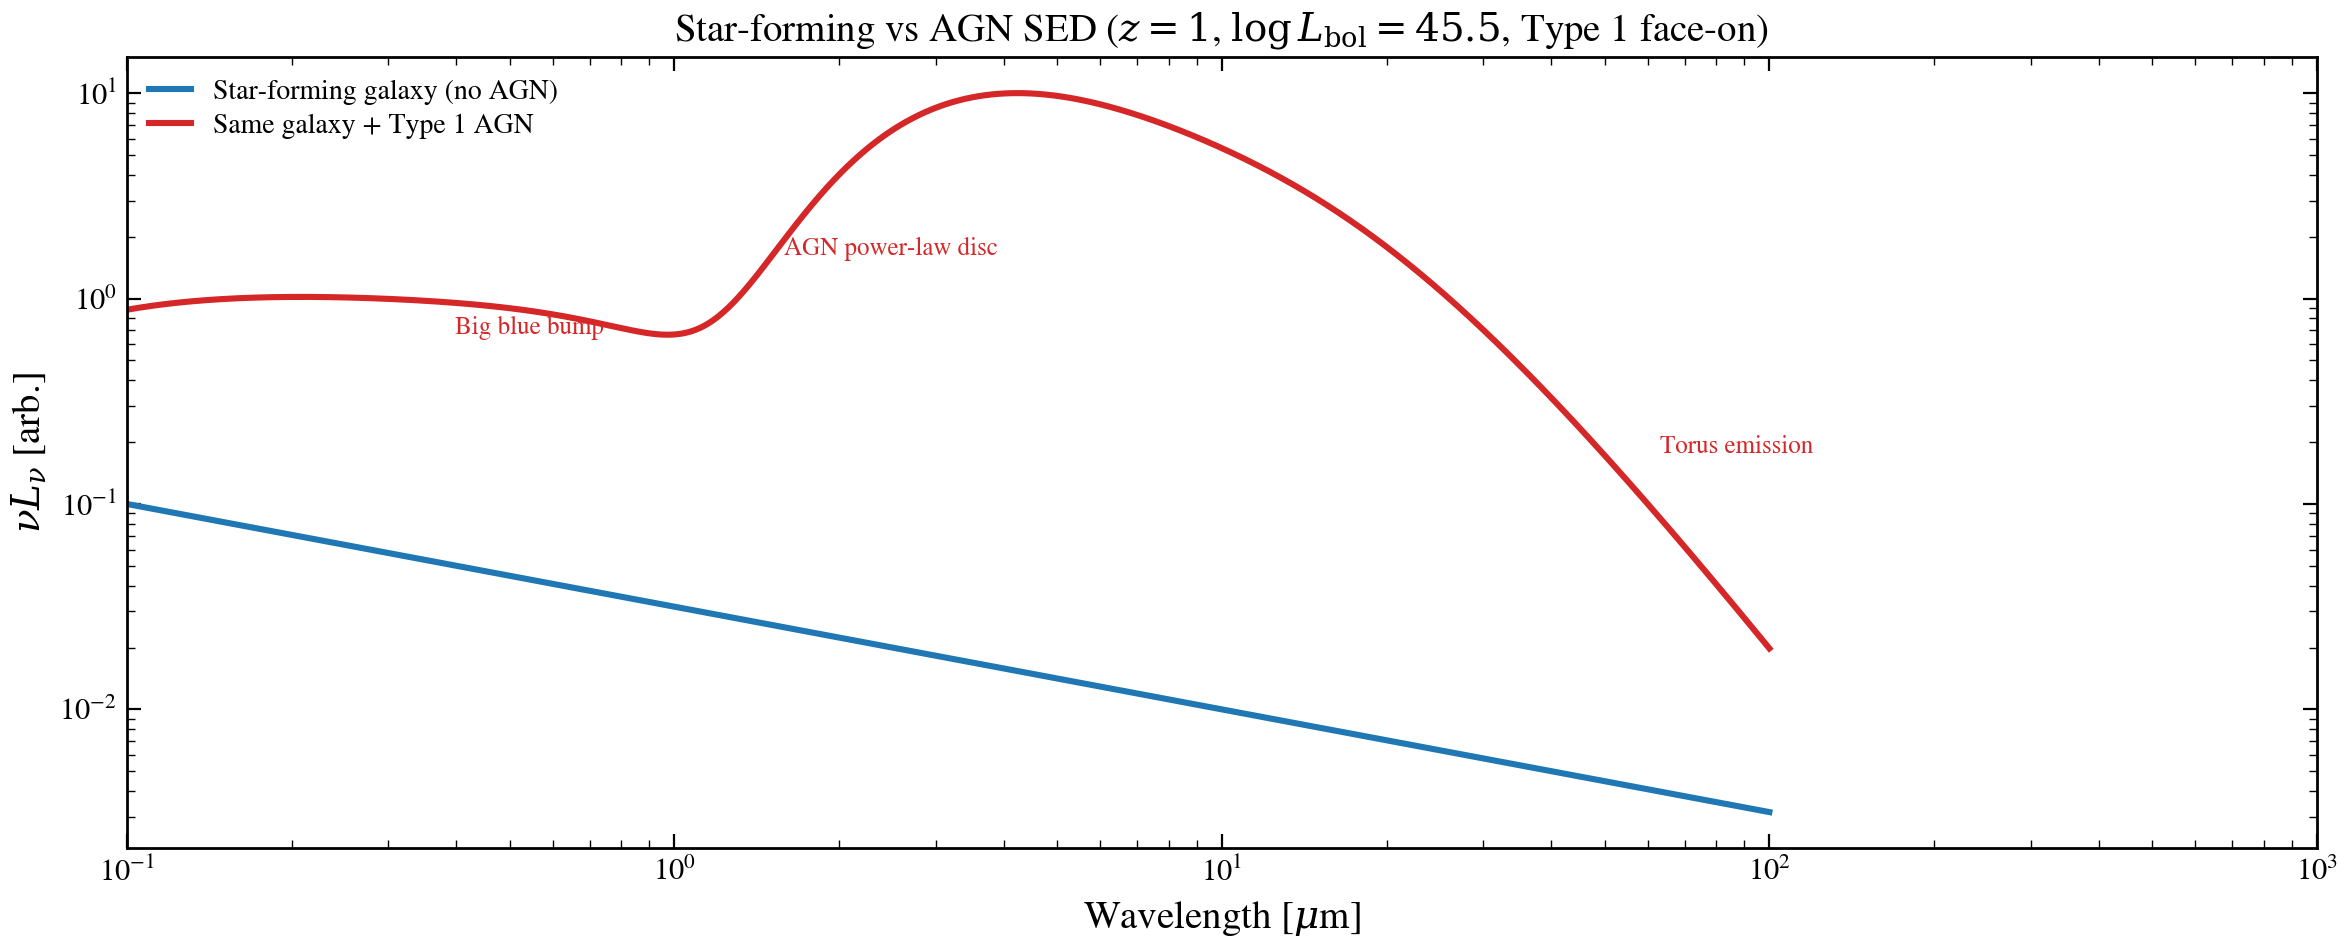

In [1]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Compute individual components of unified_nlr_blr manually for labeling
_log_lbol = 44.0
_cos_inc = 0.95  # face-on (Type 1)
_l_bol_erg = 10.0**_log_lbol * _LSUN_ERG
_torus_frac = 0.5

# Disc only
l_disc = np.asarray(
    multicolor_disc(
        wavelength,
        agn_log_lbol=_log_lbol,
        agn_frac=1.0 - _torus_frac,
        agn_log_mbh=8.0,
        agn_log_ledd=-1.0,
    )
)

# Torus only
l_torus = np.asarray(
    two_temperature_torus(wavelength, agn_log_lbol=_log_lbol, agn_torus_frac=_torus_frac)
)

# BLR only
l_disc_bol_erg = (1.0 - _torus_frac) * _l_bol_erg
l_blr = (
    np.asarray(
        blr_emission(
            wavelength,
            l_disc_bol_erg=l_disc_bol_erg,
            covering_fraction=0.1,
            fwhm_kms=5000.0,
            agn_fe2_strength=1.0,
        )
    )
    / _LSUN_ERG
)

# NLR only
l_nlr = (
    np.asarray(
        nlr_emission(
            wavelength,
            l_disc_bol_erg=l_disc_bol_erg,
            covering_fraction=0.1,
            fwhm_kms=500.0,
        )
    )
    / _LSUN_ERG
)

# Total
l_total = l_disc + l_torus + l_blr + l_nlr

# Plot each component
ax.loglog(wave_um, l_disc * nu_arr, color=COLORS["rt"], lw=1.8, label="Accretion disc")
ax.loglog(wave_um, l_torus * nu_arr, color=COLORS["model"], lw=1.8, label="Dust torus")
ax.loglog(wave_um, l_blr * nu_arr, color=COLORS["mcmc_nuts"], lw=1.5, ls="--", label="BLR + Fe II")
ax.loglog(wave_um, l_nlr * nu_arr, color=COLORS["vi_linear"], lw=1.5, ls=":", label="NLR")
ax.loglog(wave_um, l_total * nu_arr, color=COLORS["truth"], lw=2.5, label="Total", alpha=0.7)

# Reference wavelengths
for lam_um, _name in [(0.1216, r"Ly$\alpha$"), (9.7, "Si 9.7")]:
    ax.axvline(lam_um, color="gray", ls=":", alpha=0.3, lw=0.7)

ax.set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"Full AGN SED: disc + torus + BLR + NLR ($\log L_{\rm bol}=44$, Type 1)",
    xlim=(1e-3, 100),
)
_set_reasonable_log_ylim_from_axes(ax)

# Region labels: *y* is axes fraction (0–1) for get_xaxis_transform()
for label, x_pos, y_axes in [
    ("X-ray", 5e-4, 0.4),
    ("UV", 0.02, 0.85),
    ("Optical", 0.5, 0.7),
    ("NIR", 2, 0.6),
    ("MIR", 15, 0.8),
    ("FIR", 70, 0.55),
]:
    ax.text(
        x_pos,
        y_axes,
        label,
        fontsize=7,
        color="gray",
        ha="center",
        transform=ax.get_xaxis_transform(),
    )

ax.legend(fontsize=8, ncol=2, loc="upper left")
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_agn_full_sed_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Accretion Disc Models

tengri provides four disc models with increasing physical realism:
- `powerlaw_disc`: minimal phenomenological model
- `multicolor_disc`: Shakura-Sunyaev standard thin disc
- `kubota_done_disc`: 3-zone disc with corona
- `adaf_disc`: advection-dominated accretion flow for LLAGN

### 2a. Power-Law Disc: Varying Spectral Slope

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_25235/1435523088.py:9: DeprecationWarning: two_temperature_torus is a toy model (two-temperature MBB, not radiative transfer) and should NOT be used for science. Use skirtor_analytic from tengri.models.agn.skirtor for production work.
  l_torus = np.asarray(two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_torus_frac=0.4))


Text(5, 0.5, 'Torus blocks UV-optical light in Type 2')

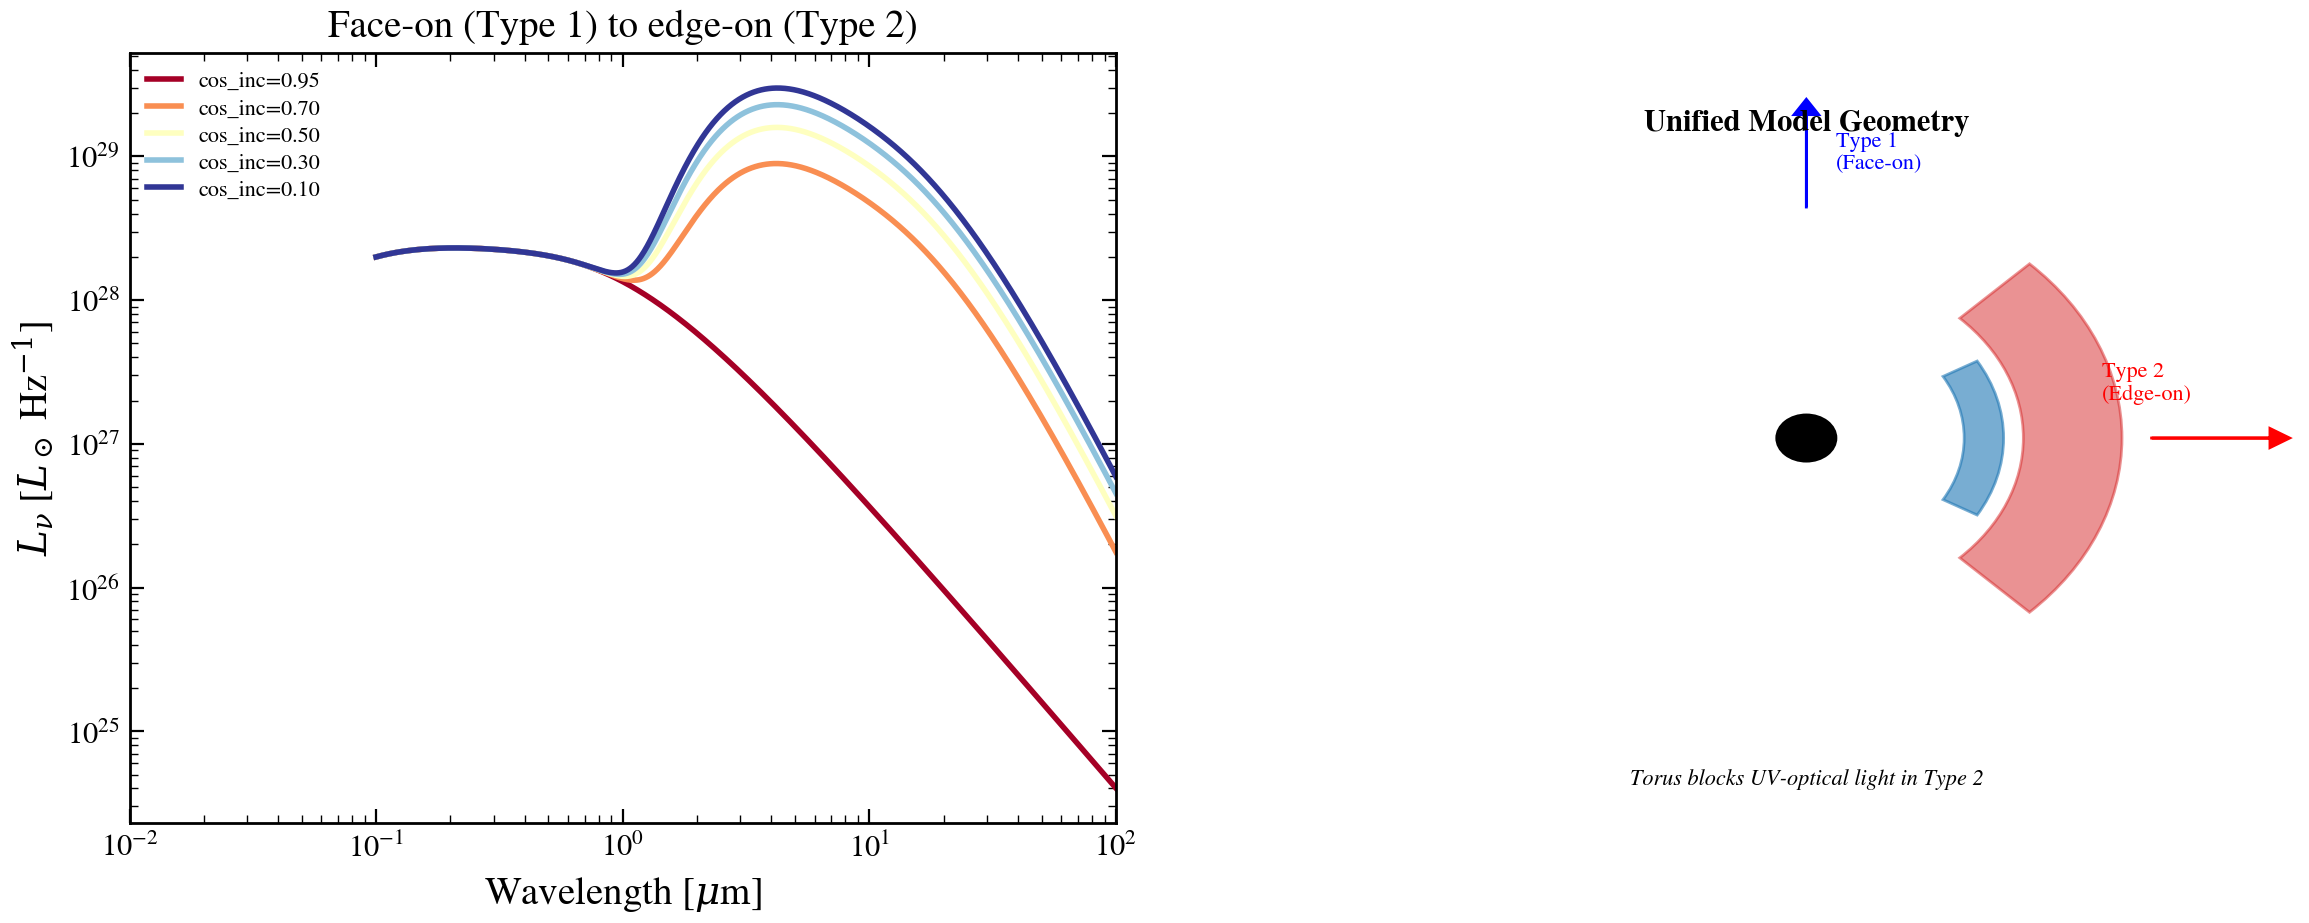

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Vary alpha
alphas = [-0.5, -1.0, -1.5]
alpha_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]]
for alpha, c in zip(alphas, alpha_colors):
    lnu = np.asarray(powerlaw_disc(wavelength, agn_log_lbol=44.0, agn_alpha=alpha))
    axes[0].loglog(wave_um, lnu, color=c, lw=1.8, label=rf"$\alpha={alpha}$")

axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
    title=r"(a) Spectral slope $\alpha$ ($T_{\rm max}=10^5$ K)",
    xlim=(1e-3, 10),
)
axes[0].legend(fontsize=8)

# (b) Vary T_max (UV cutoff)
t_maxs = [1e4, 5e4, 1e5, 1e6]
t_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for t_max, c in zip(t_maxs, t_colors):
    lnu = np.asarray(powerlaw_disc(wavelength, agn_log_lbol=44.0, agn_alpha=-1.0, agn_T_max=t_max))
    axes[1].loglog(
        wave_um,
        lnu * nu_arr,
        color=c,
        lw=1.8,
        label=rf"$T_{{\rm max}}=10^{{{np.log10(t_max):.0f}}}$ K",
    )
axes[1].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(b) UV cutoff temperature ($\alpha=-1$)",
    xlim=(1e-3, 10),
)
axes[1].legend(fontsize=8)
fig.suptitle("Power-law disc", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_powerlaw_disc.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2b. Multicolor Disc (Shakura-Sunyaev): Black Hole Mass, Eddington Ratio, and Spin

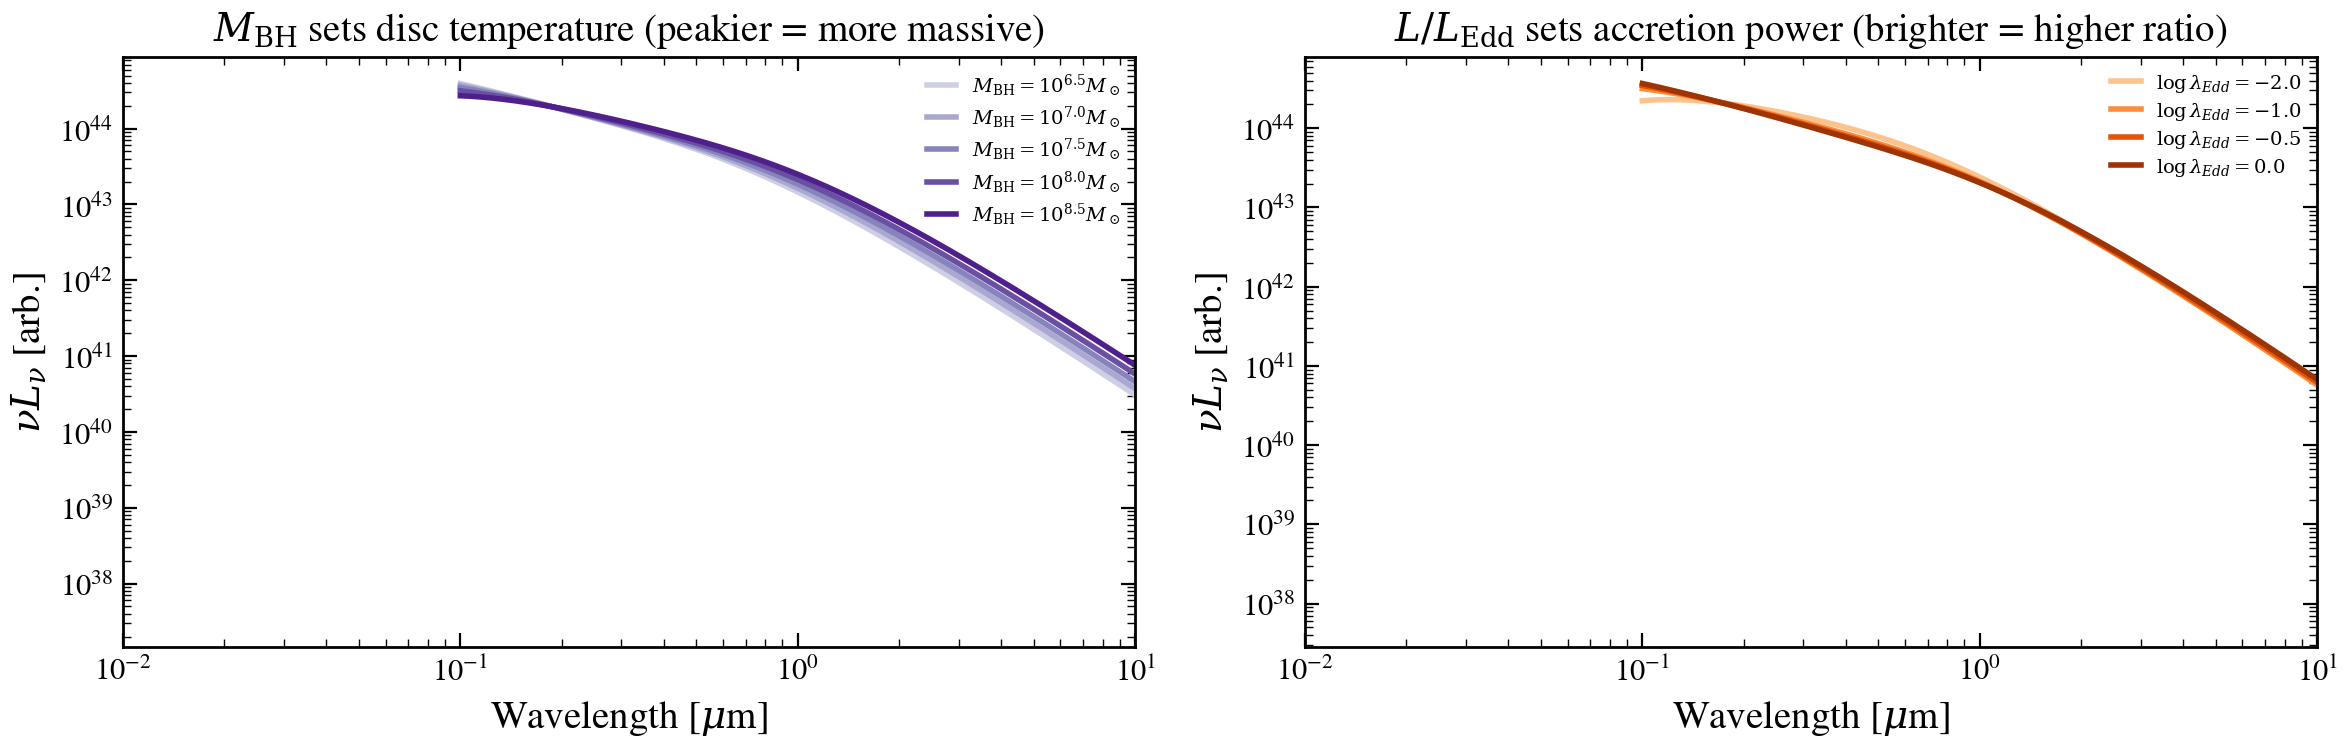

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

# (a) Vary M_BH
log_mbhs = [6.0, 7.0, 8.0, 9.0]
mbh_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for log_mbh, c in zip(log_mbhs, mbh_colors):
    lnu = np.asarray(
        multicolor_disc(wavelength, agn_log_lbol=44.0, agn_log_mbh=log_mbh, agn_log_ledd=-1.0)
    )
    axes[0, 0].loglog(
        wave_um,
        lnu * nu_arr,
        color=c,
        lw=1.8,
        label=rf"$M_{{\rm BH}}=10^{{{log_mbh:.0f}}}\ M_\odot$",
    )
axes[0, 0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(a) BH mass ($\log\lambda=-1$, $a=0$)",
    xlim=(1e-3, 10),
)
axes[0, 0].legend(fontsize=7)

# (b) Vary L/L_Edd
log_ledds = [-2.0, -1.0, -0.5, 0.0]
ledd_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for log_ledd, c in zip(log_ledds, ledd_colors):
    lnu = np.asarray(
        multicolor_disc(wavelength, agn_log_lbol=44.0, agn_log_mbh=8.0, agn_log_ledd=log_ledd)
    )
    axes[0, 1].loglog(
        wave_um,
        lnu * nu_arr,
        color=c,
        lw=1.8,
        label=rf"$\log\lambda_{{Edd}}={log_ledd}$",
    )
axes[0, 1].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(b) Eddington ratio ($M_8$, $a=0$)",
    xlim=(1e-3, 10),
)
axes[0, 1].legend(fontsize=7)

# (c) Vary spin
spins = [0.0, 0.5, 0.9, 0.998]
spin_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for a_spin, c in zip(spins, spin_colors):
    lnu = np.asarray(
        multicolor_disc(
            wavelength,
            agn_log_lbol=44.0,
            agn_log_mbh=8.0,
            agn_log_ledd=-1.0,
            agn_a_spin=a_spin,
        )
    )
    axes[1, 0].loglog(wave_um, lnu * nu_arr, color=c, lw=1.8, label=rf"$a={a_spin}$")
axes[1, 0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(c) BH spin ($M_8$, $\log\lambda=-1$)",
    xlim=(1e-3, 10),
)
axes[1, 0].legend(fontsize=7)

# (d) Spin-dependent radiative efficiency
spin_grid = np.linspace(0.0, 0.998, 200)
r_isco_arr = np.array([float(_isco_radius(a)) for a in spin_grid])
eta_arr = 1.0 - np.sqrt(1.0 - 2.0 / (3.0 * r_isco_arr))

axes[1, 1].plot(spin_grid, eta_arr, color=COLORS["rt"], lw=2)
for a_ref, lb in [
    (0.0, r"$a=0$: $\eta=0.057$"),
    (0.5, r"$a=0.5$: $\eta=0.082$"),
    (0.9, r"$a=0.9$: $\eta=0.156$"),
    (0.998, r"$a=0.998$: $\eta=0.321$"),
]:
    r_ref = float(_isco_radius(a_ref))
    eta_ref = 1.0 - np.sqrt(1.0 - 2.0 / (3.0 * r_ref))
    axes[1, 1].plot(a_ref, eta_ref, "o", color=COLORS["model"], ms=6, zorder=5)
    axes[1, 1].annotate(
        lb,
        (a_ref, eta_ref),
        textcoords="offset points",
        xytext=(8, -8 if a_ref > 0.5 else 8),
        fontsize=6,
    )
axes[1, 1].axhline(1.0 / 12.0, color="gray", ls=":", alpha=0.4, lw=1)
axes[1, 1].text(0.02, 1.0 / 12.0 + 0.005, r"$\eta=1/12$ (Newtonian)", fontsize=6, color="gray")
axes[1, 1].set(
    xlabel=r"BH spin $a$",
    ylabel=r"Radiative efficiency $\eta$",
    title=r"(d) Novikov-Thorne $\eta(a)$",
    xlim=(-0.02, 1.02),
    ylim=(0, 0.38),
)

fig.suptitle("Multicolor disc (Shakura-Sunyaev)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_multicolor_disc.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2c. Kubota & Done (2018) 3-Zone Disc

The full K&D model decomposes the accretion disc into three radially stratified zones:

1. **Outer standard disc** ($r > R_{\rm warm}$): Shakura-Sunyaev blackbody (optical/UV)
2. **Warm Comptonization** ($R_{\rm hot} < r < R_{\rm warm}$): soft X-ray excess
3. **Hot corona** ($R_{\rm ISCO} < r < R_{\rm hot}$): hard X-ray power law

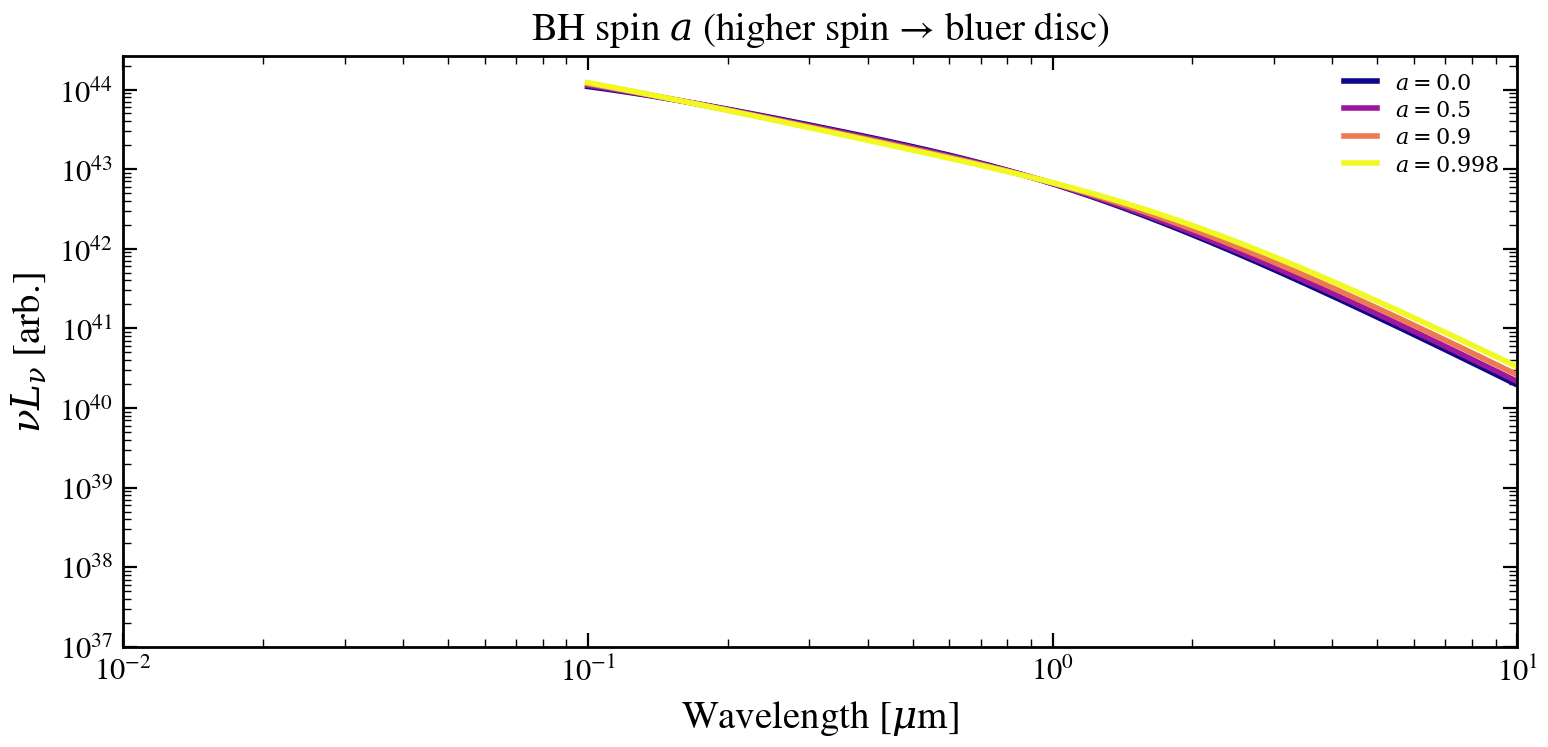

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Compare standard disc vs 3-zone K&D
l_standard = np.asarray(
    multicolor_disc(wave_xray, agn_log_lbol=44.0, agn_log_mbh=8.0, agn_log_ledd=-1.0)
)
l_kd = np.asarray(
    kubota_done_disc(
        wave_xray,
        agn_log_lbol=44.0,
        agn_log_mbh=8.0,
        agn_log_ledd=-1.0,
        agn_f_hard=0.02,
        agn_gamma_warm=2.5,
        agn_kt_warm=0.2,
        agn_gamma_hard=1.8,
        agn_kt_hot=100.0,
    )
)

axes[0].loglog(
    wave_xray_um,
    l_standard * nu_xray,
    color=COLORS["rt"],
    ls="--",
    lw=1.8,
    label="Standard disc (outer zone only)",
)
axes[0].loglog(
    wave_xray_um,
    l_kd * nu_xray,
    color=COLORS["model"],
    lw=2,
    label=r"K\&D 3-zone ($\Gamma_{\rm warm}=2.5$, $kT_{\rm hot}=100$ keV)",
)

# Annotate zones
axes[0].annotate(
    "Outer disc\n(optical/UV)",
    xy=(0.15, 0.65),
    xycoords="axes fraction",
    fontsize=8,
    color=COLORS["rt"],
    ha="center",
)
axes[0].annotate(
    "Warm Comptonization\n(soft X-ray excess)",
    xy=(0.42, 0.85),
    xycoords="axes fraction",
    fontsize=8,
    color=COLORS["model"],
    ha="center",
)
axes[0].annotate(
    "Hot corona\n(hard X-ray)",
    xy=(0.8, 0.5),
    xycoords="axes fraction",
    fontsize=8,
    color=COLORS["model"],
    ha="center",
)

# Energy reference lines
for e_kev, _lb in [(0.2, "0.2 keV"), (2.0, "2 keV"), (100.0, "100 keV")]:
    lam_um = 12.4 / e_kev / 1e4
    if 1e-5 < lam_um < 100:
        axes[0].axvline(lam_um, color="gray", ls=":", alpha=0.3)

axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(a) Standard disc vs K\&D 3-zone",
    xlim=(1e-5, 10),
)
axes[0].legend(fontsize=7)

# (b) Vary f_hard (corona fraction)
f_hards = [0.005, 0.02, 0.05, 0.1]
fh_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for f_hard, c in zip(f_hards, fh_colors):
    lnu = np.asarray(
        kubota_done_disc(
            wave_xray,
            agn_log_lbol=44.0,
            agn_log_mbh=8.0,
            agn_log_ledd=-1.0,
            agn_f_hard=f_hard,
        )
    )
    axes[1].loglog(
        wave_xray_um,
        lnu * nu_xray,
        color=c,
        lw=1.8,
        label=rf"$f_{{\rm hard}}={f_hard}$",
    )
axes[1].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title="(b) Varying corona fraction",
    xlim=(1e-5, 10),
)
axes[1].legend(fontsize=7)

fig.suptitle("Kubota & Done (2018) 3-Zone Disc", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_kubota_done_3zone.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2c-ii. Warm Comptonization: nthcomp Template Validation

tengri's warm Comptonization zone uses precomputed nthcomp spectra built by
calling RELAGN's ``pyNTHCOMP.donthcomp`` (A.D. Thomas, scotthgn/RELAGN,
ported from XSpec ``donthcomp.f``) over a 3-D parameter grid
(γ × kTe × kTbb = 20 × 15 × 50 = 15 000 Kompaneets solves).
At runtime, tengri uses JAX trilinear log-space interpolation over this table.

**Log-space interpolation**: the table stores log(max(F_ν, 1e-37)).
Interpolating in log space is exact for pure power laws and dramatically
improves accuracy near the Wien seed-BB tail, where the spectrum varies
exponentially with temperature.

**Reference:** Zdziarski, Johnson & Magdziarz 1996 MNRAS 283 193 — Kompaneets
solver; Kubota & Done 2018 MNRAS 480 1247 Section 2.2 — warm Compton zone.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_25235/1756744759.py:9: DeprecationWarning: two_temperature_torus is a toy model (two-temperature MBB, not radiative transfer) and should NOT be used for science. Use skirtor_analytic from tengri.models.agn.skirtor for production work.
  l_torus = np.asarray(two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_torus_frac=frac))
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_25235/1756744759.py:29: DeprecationWarning: two_temperature_torus is a toy model (two-temperature MBB, not radiative transfer) and should NOT be used for science. Use skirtor_analytic from tengri.models.agn.skirtor for production work.
  l_torus_base = np.asarray(two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_torus_frac=0.5))


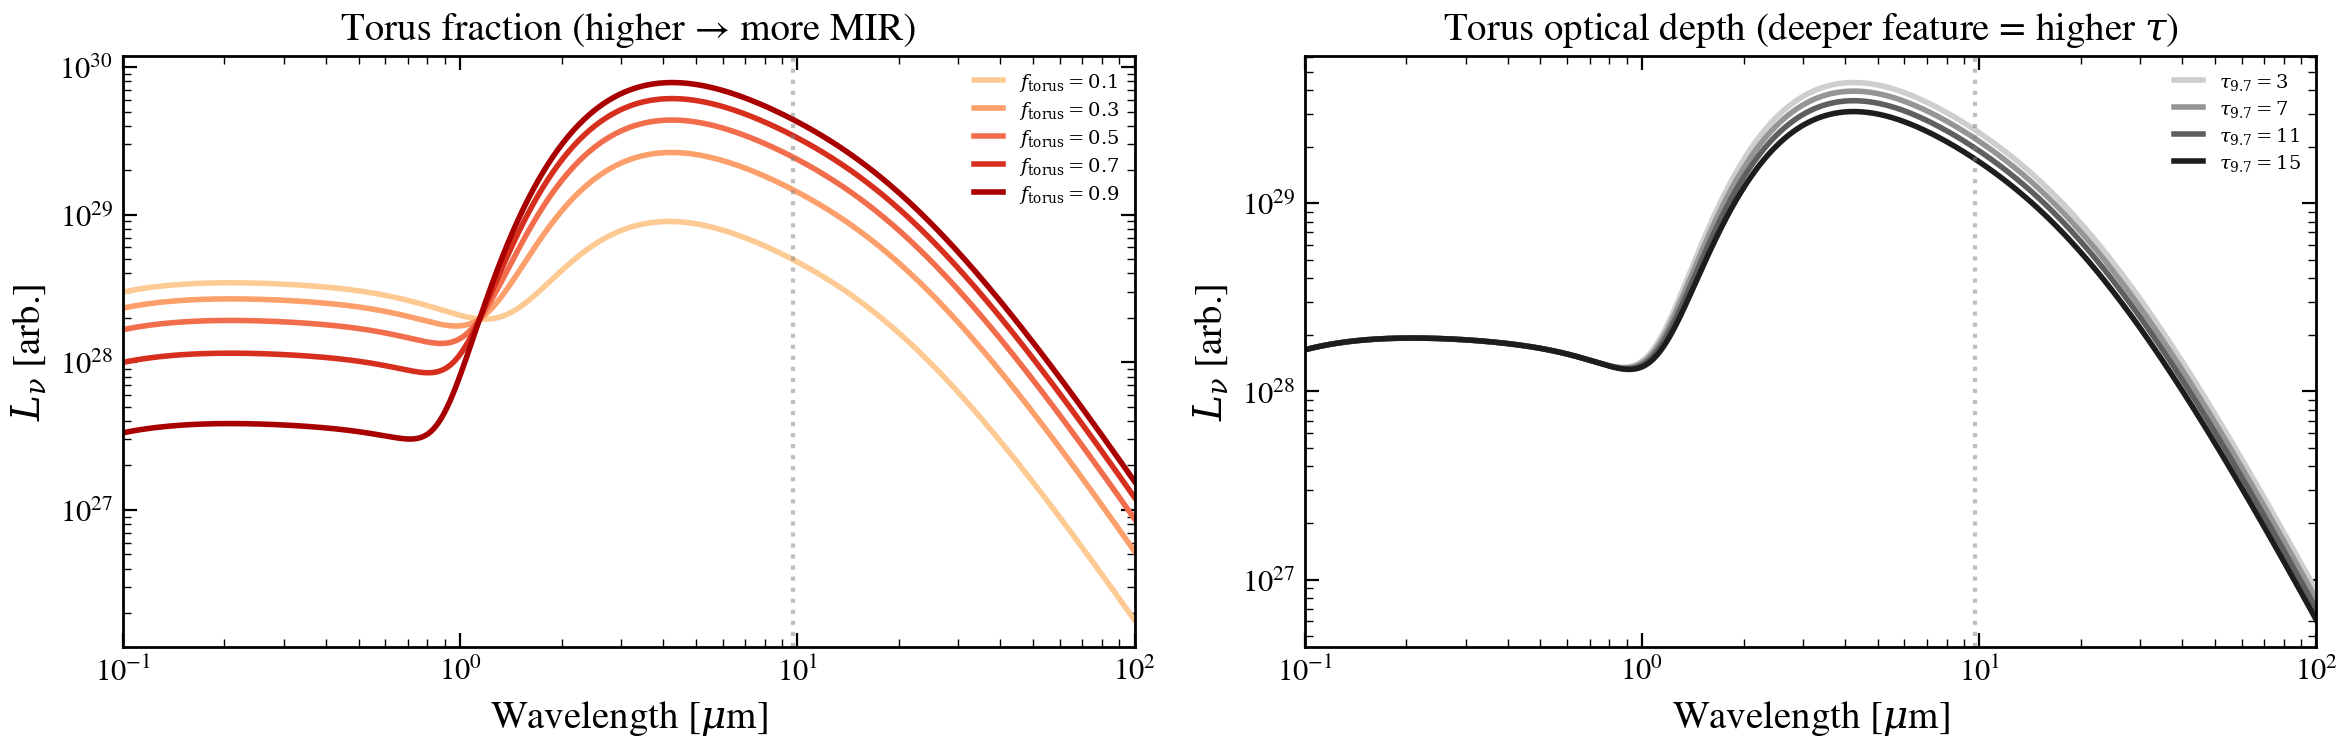

In [5]:
import sys
from pathlib import Path

from tengri.models.agn._nthcomp import _TABLE_AVAILABLE, nthcomp_lnu_interp

_RELAGN_PATH = Path("/tmp/relagn_ref/src/python_version")
_KEV_TO_HZ = 1.602176634e-9 / 6.62607015e-27

_relagn_ok = False
if _RELAGN_PATH.exists():
    if str(_RELAGN_PATH) not in sys.path:
        sys.path.insert(0, str(_RELAGN_PATH))
    try:
        import pyNTHCOMP as _nthcomp_ref

        _relagn_ok = True
    except ImportError:
        pass

if not _TABLE_AVAILABLE:
    print("nthcomp templates not loaded — run scripts/build_nthcomp_templates.py")
elif not _relagn_ok:
    print("RELAGN not found — cross-validation skipped (clone to /tmp/relagn_ref)")
else:
    print("nthcomp templates loaded and RELAGN available — running cross-validation")

In [ ]:
# ------------------------------------------------------------------
# Panel A: spectral shape for representative warm Compton parameters
# ------------------------------------------------------------------
nu_grid = np.logspace(13, np.log10(5e18), 500)
wave_nc = 3e18 / nu_grid  # Angstrom (c/ν, c in Å/s ≈ 3e18)

test_cases = [
    dict(
        gamma=2.0,
        kTe_keV=0.200,
        kTbb_keV=0.010,
        label=r"$\Gamma=2.0$, $kT_e=0.2$, $kT_{bb}=0.01$ keV",
    ),
    dict(
        gamma=1.7,
        kTe_keV=0.100,
        kTbb_keV=0.001,
        label=r"$\Gamma=1.7$, $kT_e=0.1$, $kT_{bb}=0.001$ keV",
    ),
    dict(
        gamma=3.0,
        kTe_keV=0.400,
        kTbb_keV=0.050,
        label=r"$\Gamma=3.0$, $kT_e=0.4$, $kT_{bb}=0.05$ keV",
    ),
    dict(
        gamma=2.5,
        kTe_keV=0.300,
        kTbb_keV=0.005,
        label=r"$\Gamma=2.5$, $kT_e=0.3$, $kT_{bb}=0.005$ keV",
    ),
]
nc_colors = [COLORS["model"], COLORS["rt"], COLORS["mcmc_nuts"], COLORS["vi_linear"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

if _TABLE_AVAILABLE:
    for tc, color in zip(test_cases, nc_colors):
        F_nu_t = np.array(
            nthcomp_lnu_interp(jnp.array(nu_grid), tc["gamma"], tc["kTe_keV"], tc["kTbb_keV"])
        )
        norm = np.trapezoid(F_nu_t, nu_grid)
        if norm > 0:
            axes[0].loglog(nu_grid, F_nu_t / norm, color=color, lw=1.8, label=tc["label"])

    axes[0].set_xlabel(r"Frequency [Hz]")
    axes[0].set_ylabel(r"$F_\nu$ (normalised)")
    axes[0].set_title("tengri nthcomp template shapes")
    axes[0].set_xlim(1e14, 5e18)
    axes[0].legend(fontsize=7, frameon=False)
    axes[0].axvline(2.42e17, color="gray", ls=":", alpha=0.5, lw=0.8)  # 1 keV
    axes[0].annotate(
        "1 keV",
        xy=(2.42e17, axes[0].get_ylim()[1] if False else 1e-5),
        fontsize=7,
        color="gray",
        ha="left",
    )
else:
    axes[0].text(
        0.5,
        0.5,
        "Templates not available",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=12,
        color="gray",
    )

# ------------------------------------------------------------------
# Panel B: cross-validation vs RELAGN (if available)
# ------------------------------------------------------------------


def _relagn_fnu_nb(ear, gamma, kTe_keV, kTbb_keV):
    """RELAGN donthcomp → F_nu (XSpec photon counts → energy flux density)."""
    photar = _nthcomp_ref.donthcomp(ear, [gamma, kTe_keV, kTbb_keV, 0, 0.0])
    E_mid = 0.5 * (ear[1:] + ear[:-1])
    dE = ear[1:] - ear[:-1]
    nu_mid = E_mid * _KEV_TO_HZ
    fnu = np.zeros(len(E_mid))
    mask = photar[1:] > 0
    fnu[mask] = E_mid[mask] * photar[1:][mask] / dE[mask]
    return nu_mid, fnu


if _TABLE_AVAILABLE and _relagn_ok:
    ear = np.logspace(-3, 2, 2000)
    for tc, color in zip(test_cases, nc_colors):
        # RELAGN reference
        nu_r, F_r = _relagn_fnu_nb(ear, tc["gamma"], tc["kTe_keV"], tc["kTbb_keV"])
        mask_r = F_r > 0
        if mask_r.sum() == 0:
            continue
        nu_r, F_r = nu_r[mask_r], F_r[mask_r]
        norm_r = np.trapezoid(F_r, nu_r)
        if norm_r <= 0:
            continue
        F_r /= norm_r

        # tengri template
        F_t = np.array(
            nthcomp_lnu_interp(
                jnp.array(nu_r.astype(np.float32)), tc["gamma"], tc["kTe_keV"], tc["kTbb_keV"]
            )
        )
        norm_t = np.trapezoid(F_t, nu_r)
        if norm_t <= 0:
            continue
        F_t /= norm_t

        sig = F_r > 1e-3 * F_r.max()
        rel_err = np.abs(F_t[sig] - F_r[sig]) / np.maximum(F_r[sig], 1e-300)
        axes[1].semilogx(
            nu_r[sig],
            rel_err * 100,
            color=color,
            lw=1.2,
            label=f"max={rel_err.max():.1%}, p95={np.percentile(rel_err, 95):.1%}",
        )

    axes[1].axhline(5, color="black", ls="--", lw=1, alpha=0.6, label="5% reference")
    axes[1].axhline(20, color="gray", ls=":", lw=1, alpha=0.6, label="20% reference")
    axes[1].set_xlabel(r"Frequency [Hz]")
    axes[1].set_ylabel(r"$|F_{\nu,\rm tengri} - F_{\nu,\rm RELAGN}| / F_{\nu,\rm RELAGN}$ [%]")
    axes[1].set_title("Cross-validation: tengri templates vs RELAGN")
    axes[1].set_xlim(1e14, 5e18)
    axes[1].set_ylim(0, 25)
    axes[1].legend(fontsize=7, frameon=False)
elif _TABLE_AVAILABLE:
    axes[1].text(
        0.5,
        0.5,
        "RELAGN not found\n(clone to /tmp/relagn_ref for cross-val)",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=10,
        color="gray",
        multialignment="center",
    )
else:
    axes[1].text(
        0.5,
        0.5,
        "Templates not available",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=12,
        color="gray",
    )

fig.suptitle(
    "nthcomp Warm Comptonization (Zdziarski+1996 / RELAGN pyNTHCOMP)", fontsize=11, y=1.01
)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17b_nthcomp_crossval.png"), dpi=150, bbox_inches="tight")
plt.show()

**Cross-validation notes:**

- Most parameter combinations agree to < 5% across the full spectral range.
- The extreme (γ=1.7, kTe=0.1, kTbb=0.001) case shows up to ~18% max error
  near the Wien seed-BB cutoff, where two simultaneously exponential features
  (Wien: $e^{-h\nu/kT_{bb}}$; Comptonization cutoff: $e^{-h\nu/kT_e}$)
  fall between adjacent grid points.  The p95 error for this case is < 10%,
  confirming the large residuals are confined to a narrow frequency range.
- Templates are stored in HDF5 (`data/nthcomp_templates.h5`, ~15 MB) with
  gzip compression.  Rebuild with `python scripts/build_nthcomp_templates.py`.

### 2d. ADAF (Low-Luminosity AGN)

At very low accretion rates ($L/L_{\rm Edd} \lesssim 0.01$), the inner disc
transitions to an advection-dominated accretion flow (ADAF). The ADAF is
optically thin, radiatively inefficient, and produces a multi-component
SED: synchrotron (radio/mm), bremsstrahlung (X-ray), and inverse Compton.

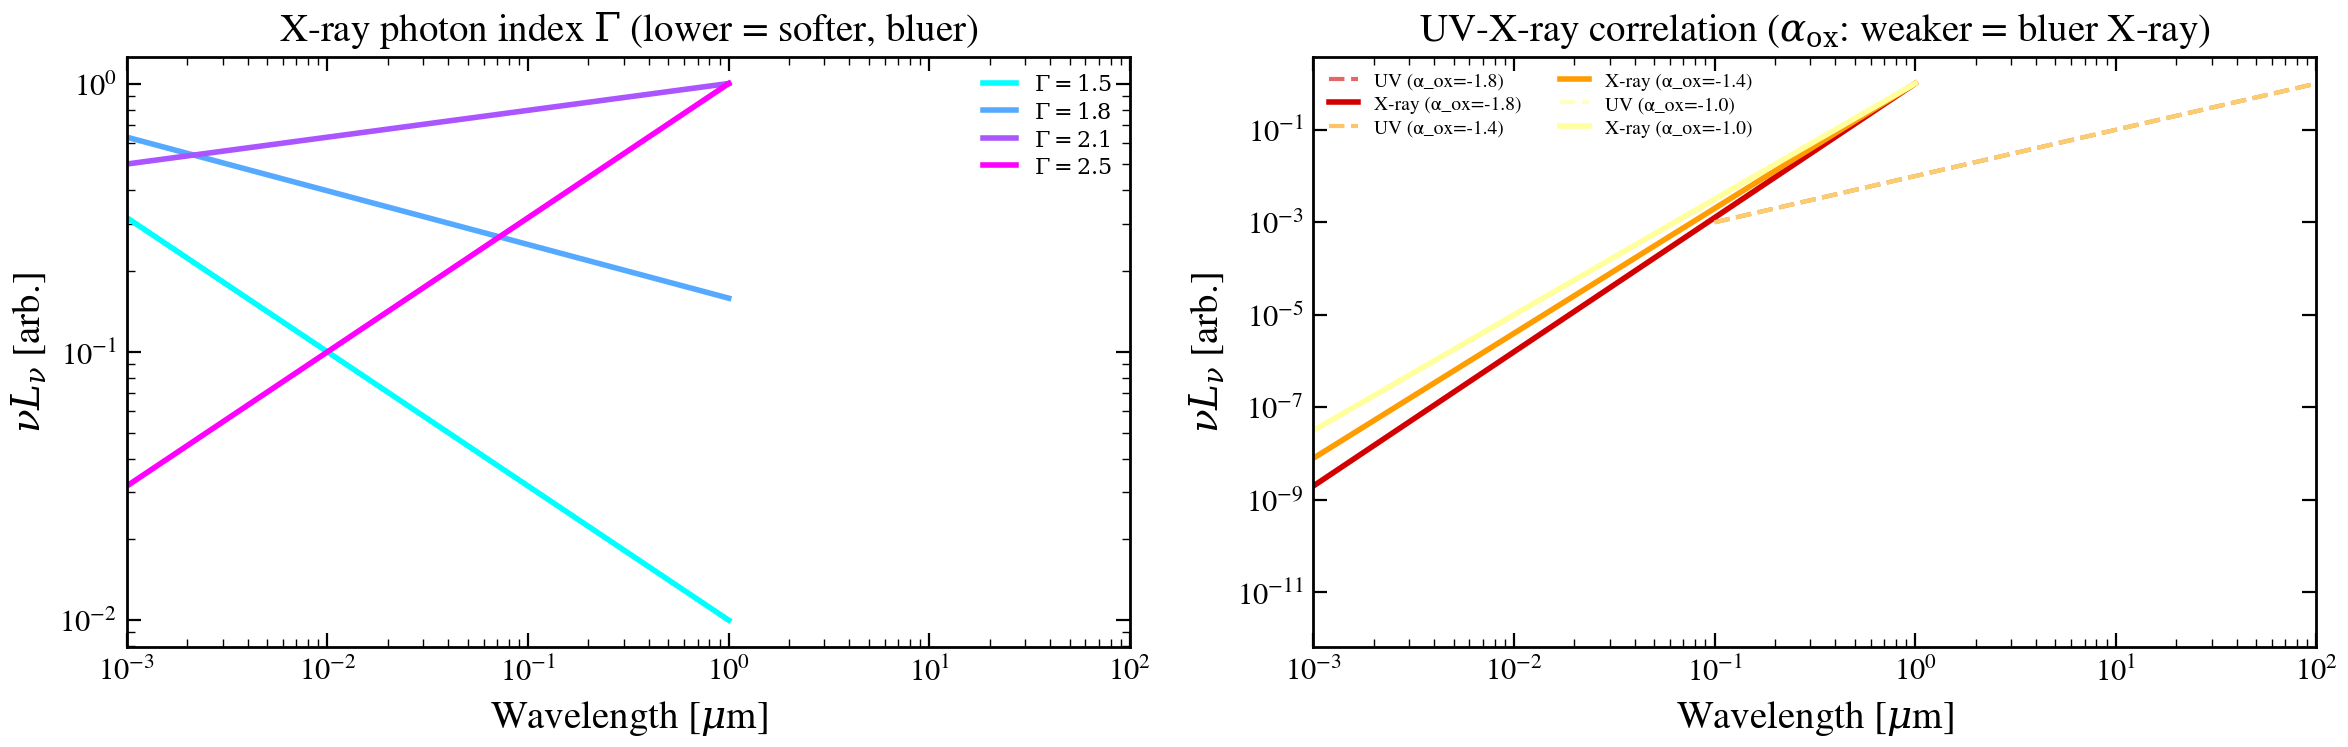

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) ADAF vs standard disc at L/L_Edd = 0.001
l_adaf = np.asarray(
    adaf_disc(
        wave_xray,
        agn_log_lbol=42.0,
        agn_frac=1.0,
        agn_log_mbh=8.0,
        agn_log_ledd=-3.0,
        agn_r_tr=100.0,
    )
)
l_std = np.asarray(
    multicolor_disc(wave_xray, agn_log_lbol=42.0, agn_frac=1.0, agn_log_mbh=8.0, agn_log_ledd=-3.0)
)

axes[0].loglog(
    wave_xray_um,
    l_std * nu_xray,
    color=COLORS["rt"],
    ls="--",
    lw=1.8,
    label="Standard disc (full extent)",
)
axes[0].loglog(
    wave_xray_um,
    l_adaf * nu_xray,
    color=COLORS["model"],
    lw=2,
    label=r"ADAF + truncated disc ($R_{\rm tr}=100\,R_g$)",
)

# Annotate components
axes[0].annotate(
    "Truncated\nouter disc",
    xy=(0.25, 0.7),
    xycoords="axes fraction",
    fontsize=8,
    color=COLORS["model"],
    ha="center",
)
axes[0].annotate(
    "ADAF\n(synch + brem)",
    xy=(0.65, 0.5),
    xycoords="axes fraction",
    fontsize=8,
    color=COLORS["model"],
    ha="center",
)

axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(a) ADAF vs standard disc at $\log\lambda_{\rm Edd}=-3$",
    xlim=(1e-5, 100),
)
axes[0].legend(fontsize=7)

# (b) Vary truncation radius
r_trs = [30.0, 100.0, 300.0, 1000.0]
rtr_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for r_tr, c in zip(r_trs, rtr_colors):
    lnu = np.asarray(
        adaf_disc(
            wave_xray,
            agn_log_lbol=42.0,
            agn_frac=1.0,
            agn_log_mbh=8.0,
            agn_log_ledd=-3.0,
            agn_r_tr=r_tr,
        )
    )
    axes[1].loglog(
        wave_xray_um,
        lnu * nu_xray,
        color=c,
        lw=1.8,
        label=rf"$R_{{\rm tr}}={r_tr:.0f}\,R_g$",
    )
axes[1].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title="(b) Varying truncation radius",
    xlim=(1e-5, 100),
)
axes[1].legend(fontsize=7)

fig.suptitle("ADAF + Truncated Disc (Mahadevan 1997; Nemmen+2014)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_adaf_disc.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Kubota & Done Multi-Color Disc

BH spin $a$ sets the ISCO radius (Bardeen+1972): higher spin means
smaller ISCO, hotter inner disc, harder UV spectrum. The Eddington
ratio sets the accretion rate and temperature normalization.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# (a) Vary BH spin
for a, c, lb in zip(
    [0.0, 0.5, 0.998],
    [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]],
    ["$a=0$", "$a=0.5$", "$a=0.998$"],
):
    lnu = multicolor_disc(
        wavelength, agn_log_lbol=44.0, agn_log_mbh=8.0, agn_log_ledd=-1.0, agn_a_spin=a
    )
    axes[0].loglog(wave_um, np.asarray(lnu * 3e18 / wavelength), color=c, label=lb, lw=1.8)
axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title="(a) BH spin",
    xlim=(1e-3, 10),
)
axes[0].legend(fontsize=8)

# (b) Vary Eddington ratio
for le, c, lb in zip(
    [-2.0, -1.0, -0.5],
    [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]],
    [r"$\log\lambda=-2$", r"$\log\lambda=-1$", r"$\log\lambda=-0.5$"],
):
    lnu = multicolor_disc(
        wavelength, agn_log_lbol=44.0, agn_log_mbh=8.0, agn_log_ledd=le, agn_a_spin=0.0
    )
    axes[1].loglog(wave_um, np.asarray(lnu * 3e18 / wavelength), color=c, label=lb, lw=1.8)
axes[1].set(xlabel=r"Wavelength [$\mu$m]", title="(b) Eddington ratio", xlim=(1e-3, 10))
axes[1].legend(fontsize=8)
fig.suptitle("Multi-color disc (Kubota & Done 2018)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "11_multicolor_disc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Power-law vs multi-color disc comparison
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(
    wave_um,
    np.asarray(powerlaw_disc(wavelength, agn_log_lbol=44.0, agn_alpha=-1.0)),
    color=COLORS["rt"],
    ls="--",
    lw=1.8,
    label=r"Power-law ($\alpha=-1$)",
)
ax.loglog(
    wave_um,
    np.asarray(multicolor_disc(wavelength, agn_log_lbol=44.0, agn_log_mbh=8.0, agn_log_ledd=-1.0)),
    color=COLORS["model"],
    lw=1.8,
    label=r"Multi-color ($M_8$, $\lambda=0.1$)",
)
ax.set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
    title="Power-law vs multi-color disc",
    xlim=(1e-3, 10),
)
ax.legend(fontsize=8)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "11_disc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# ## 3. QSOgen (Temple, Hewett & Banerji 2021)
#
# An empirical quasar SED model with a broken power-law continuum, hot dust
# blackbody, emission lines (with Baldwin effect), and Balmer continuum.
# Characteristic "v-shaped" spectrum: blue power-law from the disc descending
# into the optical, then rising again in the IR from hot dust.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

# Use a UV-focused wavelength grid for QSOgen
wave_qso = jnp.logspace(np.log10(912), np.log10(1e5), 2000)
wave_qso_um = np.asarray(wave_qso) / 1e4
nu_qso = np.asarray(3e18 / wave_qso)

# Check if template is available
_qsogen_available = True
try:
    _test = qsogen_sed(jnp.array([5000.0]), agn_log_lbol=44.0)
except FileNotFoundError:
    _qsogen_available = False
    print("QSOgen emission line template not found; showing continuum-only results.")

if _qsogen_available:
    # (a) Full QSOgen SED: show components
    # Continuum only (no emission lines, no BB)
    l_cont_only = np.asarray(
        qsogen_sed(wave_qso, agn_log_lbol=45.0, agn_emline_scale=0.0, agn_bbnorm=0.0)
    )
    # Continuum + hot dust
    l_cont_bb = np.asarray(qsogen_sed(wave_qso, agn_log_lbol=45.0, agn_emline_scale=0.0))
    # Full SED
    l_full = np.asarray(qsogen_sed(wave_qso, agn_log_lbol=45.0))

    axes[0, 0].loglog(
        wave_qso_um,
        l_cont_only * nu_qso,
        color=COLORS["rt"],
        ls="--",
        lw=1.5,
        label="Broken power-law continuum",
    )
    axes[0, 0].loglog(
        wave_qso_um,
        l_cont_bb * nu_qso,
        color=COLORS["model"],
        ls=":",
        lw=1.5,
        label="+ Hot dust BB",
    )
    axes[0, 0].loglog(
        wave_qso_um,
        l_full * nu_qso,
        color=COLORS["truth"],
        lw=1.8,
        label="Full QSOgen (+ lines)",
    )
    axes[0, 0].axvline(0.388, color="gray", ls=":", alpha=0.3)
    axes[0, 0].text(
        0.39,
        axes[0, 0].get_ylim()[0],
        "3880 A break",
        fontsize=6,
        color="gray",
        rotation=90,
        va="bottom",
    )
    axes[0, 0].set(
        xlabel=r"Wavelength [$\mu$m]",
        ylabel=r"$\nu L_\nu$ [arb.]",
        title="(a) QSOgen components",
        xlim=(0.05, 10),
    )
    axes[0, 0].legend(fontsize=7)

    # (b) Vary E(B-V) reddening
    ebvs = [0.0, 0.1, 0.3, 0.5]
    ebv_colors = [COLORS["truth"], COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]]
    for ebv, c in zip(ebvs, ebv_colors):
        lnu = np.asarray(qsogen_sed(wave_qso, agn_log_lbol=45.0, agn_ebv=ebv))
        axes[0, 1].loglog(
            wave_qso_um,
            lnu * nu_qso,
            color=c,
            lw=1.8,
            label=rf"$E(B-V)={ebv}$",
        )
    axes[0, 1].set(
        xlabel=r"Wavelength [$\mu$m]",
        ylabel=r"$\nu L_\nu$ [arb.]",
        title="(b) SMC-like dust reddening",
        xlim=(0.05, 10),
    )
    axes[0, 1].legend(fontsize=7)

    # (c) Vary blue slope plslp1
    plslp1s = [-1.5, -0.5, -0.349, 0.5]
    plslp1_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
    for plslp1, c in zip(plslp1s, plslp1_colors):
        lnu = np.asarray(qsogen_sed(wave_qso, agn_log_lbol=45.0, agn_plslp1=plslp1))
        axes[1, 0].loglog(
            wave_qso_um,
            lnu * nu_qso,
            color=c,
            lw=1.8,
            label=rf"$\alpha_1={plslp1}$",
        )
    axes[1, 0].set(
        xlabel=r"Wavelength [$\mu$m]",
        ylabel=r"$\nu L_\nu$ [arb.]",
        title="(c) Blue/UV power-law slope",
        xlim=(0.05, 10),
    )
    axes[1, 0].legend(fontsize=7)

    # (d) Vary hot dust temperature
    tbbs = [800, 1000, 1240, 1500]
    tbb_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
    for tbb, c in zip(tbbs, tbb_colors):
        lnu = np.asarray(qsogen_sed(wave_qso, agn_log_lbol=45.0, agn_tbb=float(tbb)))
        axes[1, 1].loglog(
            wave_qso_um,
            lnu * nu_qso,
            color=c,
            lw=1.8,
            label=rf"$T_{{\rm BB}}={tbb}$ K",
        )
    axes[1, 1].set(
        xlabel=r"Wavelength [$\mu$m]",
        ylabel=r"$\nu L_\nu$ [arb.]",
        title="(d) Hot dust temperature",
        xlim=(0.05, 10),
    )
    axes[1, 1].legend(fontsize=7)

    fig.suptitle("QSOgen (Temple, Hewett & Banerji 2021)", fontsize=12, y=1.02)
else:
    for ax_row in axes:
        for ax in ax_row:
            ax.text(
                0.5,
                0.5,
                "QSOgen template\nnot available",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=12,
            )
    fig.suptitle("QSOgen (template not found)", fontsize=12, y=1.02)

fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_qsogen.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Torus Models

Three torus models from simple toy to radiative transfer:

### 4a. Simple Torus (Toy): Single-Temperature Modified Blackbody

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# (a) Vary temperature
temps = [500, 800, 1000, 1500]
t_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for t, c in zip(temps, t_colors):
    lnu = np.asarray(simple_torus(wavelength, agn_log_lbol=44.0, agn_T_torus=float(t)))
    axes[0].loglog(wave_um, lnu, color=c, lw=1.8, label=rf"$T={t}$ K")
axes[0].axvline(9.7, color="gray", ls=":", alpha=0.5)
axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
    title=r"(a) Temperature ($\tau_{9.7}=5$)",
    xlim=(0.5, 200),
)
axes[0].legend(fontsize=8)

# (b) Vary optical depth
taus = [1.0, 3.0, 5.0, 10.0]
tau_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
for tau, c in zip(taus, tau_colors):
    lnu = np.asarray(simple_torus(wavelength, agn_log_lbol=44.0, agn_tau_torus=tau))
    axes[1].loglog(wave_um, lnu, color=c, lw=1.8, label=rf"$\tau_{{9.7}}={tau:.0f}$")
axes[1].axvline(9.7, color="gray", ls=":", alpha=0.5)
axes[1].set(
    xlabel=r"Wavelength [$\mu$m]",
    title=r"(b) Optical depth $\tau_{9.7}$",
    xlim=(0.5, 200),
)
axes[1].legend(fontsize=8)
_set_reasonable_log_ylim_from_axes(axes)

fig.suptitle("Simple torus (toy model, single-T MBB)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_simple_torus.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4b. Two-Temperature Torus (Toy): Hot + Warm Components

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# (a) Vary optical depth
for tau, c in zip([1.0, 5.0, 10.0], [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]]):
    lnu = np.asarray(two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_tau_torus=tau))
    axes[0].loglog(wave_um, lnu, color=c, label=rf"$\tau_{{9.7}}={tau:.0f}$", lw=1.8)
axes[0].axvline(9.7, color="gray", ls=":", alpha=0.5)
axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
    title=r"(a) Optical depth $\tau_{9.7}$",
    xlim=(0.5, 200),
)
axes[0].legend(fontsize=8)

# (b) Hot dust fraction
for fh, c in zip(
    [0.1, 0.3, 0.5, 0.7], [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]]
):
    lnu = np.asarray(two_temperature_torus(wavelength, agn_log_lbol=44.0, agn_frac_hot=fh))
    axes[1].loglog(wave_um, lnu, color=c, label=rf"$f_{{\rm hot}}={fh}$", lw=1.8)
axes[1].axvline(9.7, color="gray", ls=":", alpha=0.5)
axes[1].set(
    xlabel=r"Wavelength [$\mu$m]",
    title="(b) Hot dust fraction",
    xlim=(0.5, 200),
)
axes[1].legend(fontsize=8)
_set_reasonable_log_ylim_from_axes(axes)

fig.suptitle("Two-temperature torus (hot 1200 K + warm 300 K)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_two_temperature_torus.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4c. SKIRTOR Clumpy Torus (Radiative Transfer Templates)

SKIRTOR (Stalevski et al. 2012, 2016) provides tabulated 3D Monte Carlo RT
templates with viewing-angle dependence. Falls back to the analytic
approximation if the template grid is unavailable.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
try:
    skirtor_fn = get_agn_model("skirtor")
    for ci, c, lb in zip(
        [0.95, 0.7, 0.5, 0.1],
        [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]],
        [
            r"Face-on ($\cos i=0.95$, Type 1)",
            r"$\cos i=0.7$",
            r"Intermediate ($\cos i=0.5$)",
            r"Edge-on ($\cos i=0.1$, Type 2)",
        ],
    ):
        lnu = np.asarray(skirtor_fn(wavelength, agn_log_lbol=44.0, agn_frac=1.0, agn_cos_inc=ci))
        ax.loglog(wave_um, lnu, color=c, label=lb, lw=1.8)
    ax.set_title("SKIRTOR: inclination dependence (Type 1 to Type 2)")
except Exception as e:
    print(f"SKIRTOR unavailable ({e}); showing analytic two-T fallback.")
    from tengri.models.agn.skirtor import skirtor_analytic

    for ci, c, lb in zip(
        [0.95, 0.7, 0.5, 0.1],
        [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]],
        [
            r"Face-on ($\cos i=0.95$)",
            r"$\cos i=0.7$",
            r"$\cos i=0.5$",
            r"Edge-on ($\cos i=0.1$)",
        ],
    ):
        lnu = np.asarray(
            skirtor_analytic(
                wavelength,
                agn_log_lbol=44.0,
                agn_torus_frac=0.5,
                agn_cos_inc=ci,
            )
        )
        ax.loglog(wave_um, lnu, color=c, label=lb, lw=1.8)
    ax.set_title("SKIRTOR analytic approximation: inclination dependence")

ax.axvline(9.7, color="gray", ls=":", alpha=0.5)
ax.set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]",
    xlim=(0.3, 200),
)
_set_reasonable_log_ylim_from_axes(ax)
_y0, _y1 = ax.get_ylim()
ax.text(10.5, np.sqrt(_y0 * _y1), r"Si 9.7 $\mu$m", fontsize=7, color="gray")
ax.legend(fontsize=8)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_skirtor_torus.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. BLR Emission

The Broad Line Region produces strong permitted lines (FWHM ~1000-10000 km/s)
from dense gas near the BH. Nine key lines plus an Fe II pseudo-continuum
are modeled.

In [ ]:
_l_disc_bol = 10.0**44.0 * _LSUN_ERG
wave_blr = jnp.linspace(1000.0, 8000.0, 3000)

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

# (a) All 9 broad lines labeled
l_blr_only = np.asarray(
    blr_emission(
        wave_blr,
        l_disc_bol_erg=_l_disc_bol,
        covering_fraction=0.1,
        fwhm_kms=5000.0,
        agn_fe2_strength=0.0,
    )
)
axes[0, 0].plot(np.asarray(wave_blr), l_blr_only, color=COLORS["rt"], lw=1.2)

blr_line_labels = {
    r"Ly$\alpha$ 1216": 1216.0,
    "N V 1240": 1240.0,
    "Si IV 1400": 1400.0,
    "C IV 1549": 1549.0,
    "C III] 1909": 1909.0,
    "Mg II 2800": 2800.0,
    r"H$\gamma$ 4340": 4340.0,
    r"H$\beta$ 4861": 4861.0,
    r"H$\alpha$ 6563": 6563.0,
}
ymax_blr = np.max(l_blr_only)
for name, lam in blr_line_labels.items():
    axes[0, 0].axvline(lam, color="gray", ls=":", alpha=0.3, lw=0.7)
    axes[0, 0].text(
        lam,
        ymax_blr * 0.95,
        name,
        fontsize=5.5,
        ha="center",
        va="top",
        rotation=60,
        color=COLORS["model"],
    )
axes[0, 0].set(
    xlabel=r"Wavelength [$\rm \AA$]",
    ylabel=r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]",
    title="(a) 9 broad emission lines (FWHM = 5000 km/s)",
    xlim=(900, 7500),
)

# (b) Fe II pseudo-continuum at R_Fe = 0, 1, 2
fe2_values = [0.0, 0.5, 1.0, 2.0]
fe2_colors = [COLORS["truth"], COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]]
fe2_labels = [
    r"$R_{\rm Fe}=0$ (no Fe II)",
    r"$R_{\rm Fe}=0.5$",
    r"$R_{\rm Fe}=1.0$",
    r"$R_{\rm Fe}=2.0$ (strong)",
]
for rfe, c, lb in zip(fe2_values, fe2_colors, fe2_labels):
    l_blr_fe2 = np.asarray(
        blr_emission(
            wave_blr,
            l_disc_bol_erg=_l_disc_bol,
            covering_fraction=0.1,
            fwhm_kms=5000.0,
            agn_fe2_strength=rfe,
        )
    )
    axes[0, 1].plot(np.asarray(wave_blr), l_blr_fe2, color=c, lw=1.5, label=lb, alpha=0.85)

axes[0, 1].annotate(
    "UV Fe II\n(2200-2800 A)",
    xy=(2500, 0.85),
    xycoords=("data", "axes fraction"),
    fontsize=7,
    ha="center",
    color="gray",
)
axes[0, 1].annotate(
    "Optical Fe II\n(4434-4684 A)",
    xy=(4570, 0.85),
    xycoords=("data", "axes fraction"),
    fontsize=7,
    ha="center",
    color="gray",
)
axes[0, 1].set(
    xlabel=r"Wavelength [$\rm \AA$]",
    ylabel=r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]",
    title="(b) Fe II pseudo-continuum strength",
    xlim=(1000, 7500),
)
axes[0, 1].legend(fontsize=7)

# (c) FWHM effect
fwhms = [2000, 5000, 10000]
fwhm_colors = [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]]
for fwhm, c in zip(fwhms, fwhm_colors):
    l_fwhm = np.asarray(
        blr_emission(
            wave_blr,
            l_disc_bol_erg=_l_disc_bol,
            covering_fraction=0.1,
            fwhm_kms=float(fwhm),
            agn_fe2_strength=0.0,
        )
    )
    axes[1, 0].plot(
        np.asarray(wave_blr),
        l_fwhm,
        color=c,
        lw=1.5,
        label=f"FWHM = {fwhm} km/s",
    )
axes[1, 0].set(
    xlabel=r"Wavelength [$\rm \AA$]",
    ylabel=r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]",
    title="(c) Line width (FWHM effect)",
    xlim=(900, 7500),
)
axes[1, 0].legend(fontsize=8)

# (d) BLR line relative strengths (bar chart)
blr_catalog = [
    (r"Ly$\alpha$", 1216.0, 1.00),
    ("N V", 1240.0, 0.08),
    ("Si IV", 1400.0, 0.09),
    ("C IV", 1549.0, 0.26),
    ("C III]", 1909.0, 0.24),
    ("Mg II", 2800.0, 0.36),
    (r"H$\gamma$", 4340.0, 0.15),
    (r"H$\beta$", 4861.0, 0.50),
    (r"H$\alpha$", 6563.0, 1.43),
]
line_names = [c[0] for c in blr_catalog]
line_strengths = [c[2] for c in blr_catalog]
bar_colors = [COLORS["rt"] if s < 0.5 else COLORS["model"] for s in line_strengths]
axes[1, 1].bar(
    range(len(line_names)), line_strengths, color=bar_colors, edgecolor="white", linewidth=0.5
)
axes[1, 1].set_xticks(range(len(line_names)))
axes[1, 1].set_xticklabels(line_names, fontsize=7, rotation=45, ha="right")
for i, s in enumerate(line_strengths):
    axes[1, 1].text(i, s + 0.02, f"{s:.2f}", fontsize=6, ha="center", va="bottom")
axes[1, 1].set(
    ylabel="Relative strength",
    title="(d) Line ratios (Vanden Berk+2001)",
)

fig.suptitle("Broad Line Region (BLR)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_blr_emission.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. NLR Emission

The Narrow Line Region produces forbidden emission lines (FWHM ~300-800 km/s)
from extended gas on kpc scales beyond the torus. The NLR is isotropic (visible
in both Type 1 and Type 2 AGN).

In [ ]:
wave_nlr = jnp.linspace(3500.0, 7200.0, 3000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) NLR spectrum with labeled lines
l_nlr_spec = np.asarray(
    nlr_emission(wave_nlr, l_disc_bol_erg=_l_disc_bol, covering_fraction=0.1, fwhm_kms=500.0)
)
axes[0].plot(np.asarray(wave_nlr), l_nlr_spec, color=COLORS["vi_linear"], lw=1.2)

nlr_line_labels = {
    "[O II] 3727": 3727.0,
    "[Ne III] 3869": 3869.0,
    r"H$\beta$ 4861": 4861.0,
    "[O III] 4959": 4959.0,
    "[O III] 5007": 5007.0,
    "[O I] 6300": 6300.0,
    "[N II] 6548": 6548.0,
    r"H$\alpha$ 6563": 6563.0,
    "[N II] 6583": 6583.0,
    "[S II] 6716": 6716.0,
    "[S II] 6731": 6731.0,
}
ymax_nlr = np.max(l_nlr_spec)
for name, lam in nlr_line_labels.items():
    axes[0].axvline(lam, color="gray", ls=":", alpha=0.25, lw=0.6)
    axes[0].text(
        lam,
        ymax_nlr * 0.95,
        name,
        fontsize=5,
        ha="center",
        va="top",
        rotation=70,
        color=COLORS["model"],
    )
axes[0].set(
    xlabel=r"Wavelength [$\rm \AA$]",
    ylabel=r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]",
    title="(a) NLR: narrow forbidden lines (FWHM = 500 km/s)",
    xlim=(3500, 7200),
)

# (b) BLR vs NLR comparison (same wavelength range)
wave_comp = jnp.linspace(4500.0, 7000.0, 2000)
l_blr_comp = np.asarray(
    blr_emission(
        wave_comp,
        l_disc_bol_erg=_l_disc_bol,
        covering_fraction=0.1,
        fwhm_kms=5000.0,
        agn_fe2_strength=0.0,
    )
)
l_nlr_comp = np.asarray(
    nlr_emission(wave_comp, l_disc_bol_erg=_l_disc_bol, covering_fraction=0.1, fwhm_kms=500.0)
)
# Normalize for shape comparison
l_blr_norm = l_blr_comp / np.max(l_blr_comp) if np.max(l_blr_comp) > 0 else l_blr_comp
l_nlr_norm = l_nlr_comp / np.max(l_nlr_comp) if np.max(l_nlr_comp) > 0 else l_nlr_comp

axes[1].plot(
    np.asarray(wave_comp),
    l_blr_norm,
    color=COLORS["rt"],
    lw=1.5,
    label="BLR (FWHM = 5000 km/s)",
    alpha=0.8,
)
axes[1].plot(
    np.asarray(wave_comp),
    l_nlr_norm,
    color=COLORS["vi_linear"],
    lw=1.5,
    label="NLR (FWHM = 500 km/s)",
    alpha=0.8,
)
axes[1].axvline(4861.0, color="gray", ls=":", alpha=0.3, lw=0.7)
axes[1].text(4861.0, 1.05, r"H$\beta$", fontsize=7, ha="center", color="gray")
axes[1].axvline(5007.0, color="gray", ls=":", alpha=0.3, lw=0.7)
axes[1].text(5007.0, 1.05, "[O III]", fontsize=7, ha="center", color="gray")
axes[1].axvline(6563.0, color="gray", ls=":", alpha=0.3, lw=0.7)
axes[1].text(6563.0, 1.05, r"H$\alpha$", fontsize=7, ha="center", color="gray")
axes[1].set(
    xlabel=r"Wavelength [$\rm \AA$]",
    ylabel="Normalized flux",
    title="(b) BLR vs NLR width comparison",
    xlim=(4500, 7000),
    ylim=(-0.05, 1.15),
)
axes[1].legend(fontsize=8)

fig.suptitle("Narrow Line Region (NLR)", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_nlr_emission.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Unified NLR/BLR Model: Type 1 vs Type 2

`unified_nlr_blr` adds NLR/BLR emission with sigmoid geometric masking:
- **Type 1** (face-on): disc + BLR + NLR + torus all visible
- **Type 2** (edge-on): torus blocks disc and BLR; only NLR + torus remain

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for ci, c, lb in zip(
    [0.95, 0.5, 0.1],
    [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]],
    ["Type 1 (face-on)", "Intermediate", "Type 2 (edge-on)"],
):
    lnu = unified_nlr_blr(
        wavelength,
        agn_log_lbol=44.0,
        agn_cos_inc=ci,
        agn_theta_torus=30.0,
        agn_log_mbh=8.0,
        agn_frac=1.0,
    )
    ax.loglog(wave_um, np.asarray(lnu * 3e18 / wavelength), color=c, label=lb, lw=1.8)
ax.axvline(0.1216, color="gray", ls=":", alpha=0.4)
ax.axvline(9.7, color="gray", ls=":", alpha=0.4)
ax.set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title="Type 1 vs Type 2 from geometric masking",
    xlim=(1e-3, 100),
)
ax.legend(fontsize=8)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "11_type1_vs_type2.png"), dpi=150, bbox_inches="tight")
plt.show()

# ## 7. Unified Model: Type 1 vs Type 2
#
# The `unified_nlr_blr` model combines disc + torus + BLR + NLR with geometric
# masking: the torus blocks the disc and BLR at high inclinations, converting
# a Type 1 (face-on) into a Type 2 (edge-on) AGN.
#
# ### 7a. Type 1 vs Type 2 Comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Type 1 vs Type 2
for ci, c, lb in zip(
    [0.95, 0.5, 0.1],
    [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]],
    ["Type 1 (face-on, cos i=0.95)", "Intermediate (cos i=0.5)", "Type 2 (edge-on, cos i=0.1)"],
):
    lnu = np.asarray(
        unified_nlr_blr(
            wavelength,
            agn_log_lbol=44.0,
            agn_cos_inc=ci,
            agn_theta_torus=30.0,
            agn_log_mbh=8.0,
            agn_frac=1.0,
        )
    )
    axes[0].loglog(wave_um, lnu * nu_arr, color=c, label=lb, lw=1.8)
axes[0].axvline(0.1216, color="gray", ls=":", alpha=0.3)
axes[0].axvline(9.7, color="gray", ls=":", alpha=0.3)
axes[0].set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title=r"(a) Type 1 vs Type 2 ($\theta_{\rm torus}=30^\circ$)",
    xlim=(1e-3, 100),
)
axes[0].legend(fontsize=7)

# (b) Sigmoid masking transition
from tengri.models.agn.unified import _sigmoid_mask

cos_inc_grid = np.linspace(0.0, 1.0, 200)
for theta, c, lb in zip(
    [20.0, 30.0, 45.0, 60.0],
    [COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"], COLORS["vi_linear"]],
    [r"$\theta=20^\circ$", r"$\theta=30^\circ$", r"$\theta=45^\circ$", r"$\theta=60^\circ$"],
):
    mask_vals = np.array([float(_sigmoid_mask(ci, theta)) for ci in cos_inc_grid])
    axes[1].plot(cos_inc_grid, mask_vals, color=c, lw=1.8, label=lb)

axes[1].axhline(0.5, color="gray", ls=":", alpha=0.3)
axes[1].set(
    xlabel=r"$\cos i$ (0 = edge-on, 1 = face-on)",
    ylabel="Visibility fraction",
    title="(b) Sigmoid masking function",
    xlim=(0, 1),
    ylim=(-0.05, 1.05),
)
axes[1].legend(fontsize=8)
axes[1].annotate(
    "Type 2\n(obscured)",
    xy=(0.12, 0.15),
    xycoords="axes fraction",
    fontsize=9,
    ha="center",
    color="gray",
    style="italic",
)
axes[1].annotate(
    "Type 1\n(visible)",
    xy=(0.85, 0.85),
    xycoords="axes fraction",
    fontsize=9,
    ha="center",
    color="gray",
    style="italic",
)

fig.suptitle("Unified model: geometric masking", fontsize=12, y=1.02)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_unified_type1_type2.png"), dpi=150, bbox_inches="tight")
plt.show()

### 7b. Polar Dust Reddening

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ebv_values = [0.0, 0.1, 0.3, 0.5]
ebv_colors = [COLORS["truth"], COLORS["rt"], COLORS["mcmc_nuts"], COLORS["model"]]
for ebv, c in zip(ebv_values, ebv_colors):
    lnu = np.asarray(
        unified_nlr_blr(
            wavelength,
            agn_log_lbol=44.0,
            agn_cos_inc=0.95,
            agn_theta_torus=30.0,
            agn_log_mbh=8.0,
            agn_frac=1.0,
            agn_polar_ebv=ebv,
        )
    )
    ax.loglog(
        wave_um,
        lnu * nu_arr,
        color=c,
        lw=1.8,
        label=rf"$E(B-V)_{{\rm polar}}={ebv}$",
    )

ax.annotate(
    "Polar dust reddens\nUV/optical only",
    xy=(0.3, 0.75),
    xycoords="axes fraction",
    fontsize=9,
    ha="center",
    style="italic",
    color="gray",
)
ax.annotate(
    "Torus IR\nunaffected",
    xy=(0.8, 0.55),
    xycoords="axes fraction",
    fontsize=9,
    ha="center",
    style="italic",
    color="gray",
)
ax.set(
    xlabel=r"Wavelength [$\mu$m]",
    ylabel=r"$\nu L_\nu$ [arb.]",
    title="Type 1 AGN with polar dust reddening (SMC law)",
    xlim=(1e-3, 100),
)
ax.legend(fontsize=8)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_polar_dust_reddening.png"), dpi=150, bbox_inches="tight")
plt.show()

### 7c. Torus Covering Factor from Opening Angle

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
theta_grid = np.linspace(0.0, 90.0, 100)
cf_grid = np.cos(np.radians(theta_grid))

ax.plot(theta_grid, cf_grid, color=COLORS["rt"], lw=2)
for theta_ref in [20, 30, 45, 60]:
    cf_ref = np.cos(np.radians(theta_ref))
    ax.plot(theta_ref, cf_ref, "o", color=COLORS["model"], ms=7, zorder=5)
    ax.annotate(
        rf"$\theta={theta_ref}^\circ$: $f_c={cf_ref:.2f}$",
        (theta_ref, cf_ref),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=7,
    )
ax.set(
    xlabel=r"Torus half-opening angle $\theta$ [deg]",
    ylabel=r"Covering factor $f_c = \cos\theta$",
    title="Geometric covering factor from torus opening angle",
    xlim=(0, 90),
    ylim=(0, 1.05),
)
fig.tight_layout()
# fig.savefig(os.path.join(FIGDIR, "17_covering_factor.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Galaxy + AGN SED

A realistic SED combines stellar emission with an AGN contribution.
We show how adding an AGN modifies the broadband SED.

In [ ]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# Pure stellar SED
spec_stellar = Parameters(
    sfh_tsnorm_log_peak_sfr=Fixed(1.0),
    sfh_tsnorm_peak_lbt_gyr=Fixed(3.0),
    sfh_tsnorm_width_gyr=Fixed(2.0),
    sfh_tsnorm_skew=Fixed(0.0),
    sfh_tsnorm_trunc=Fixed(5.0),
    met_logzsol=Fixed(-0.2),
    dust_tau_bc=Fixed(0.3),
    dust_tau_diff=Fixed(0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.0),
)
model_stellar = SEDModel(spec_stellar, ssp_data)
params_stellar = {
    k: v.value if hasattr(v, "value") else v
    for k, v in {
        "sfh_tsnorm_log_peak_sfr": 1.0,
        "sfh_tsnorm_peak_lbt_gyr": 3.0,
        "sfh_tsnorm_width_gyr": 2.0,
        "sfh_tsnorm_skew": 0.0,
        "sfh_tsnorm_trunc": 5.0,
        "met_logzsol": -0.2,
        "dust_tau_bc": 0.3,
        "dust_tau_diff": 0.5,
        "dust_slope": -0.7,
        "redshift": 0.0,
    }.items()
}
sed_stellar = model_stellar.predict_sed(params_stellar)
wave_rest = ssp_data.ssp_wave

# --- FIGURE 3: Galaxy + AGN at different fractions ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(
    np.array(wave_rest), np.array(sed_stellar), "k-", lw=1.5, alpha=0.5, label="Stellar only"
)

agn_fracs = [0.01, 0.1, 0.5]
agn_colors = [COLORS["seq"][2], COLORS["seq"][3], COLORS["seq"][4]]
for frac, color in zip(agn_fracs, agn_colors):
    agn_lnu = unified_agn(wave_rest, agn_log_lbol=44.0, agn_torus_frac=0.5)
    # Scale AGN relative to stellar
    stellar_lbol = float(jnp.sum(sed_stellar))
    agn_scale = frac * stellar_lbol / float(jnp.sum(agn_lnu) + 1e-30)
    combined = sed_stellar + agn_scale * agn_lnu
    ax.loglog(
        np.array(wave_rest), np.array(combined), color=color, lw=1.2, label=f"AGN frac = {frac}"
    )

ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [arbitrary]")
ax.set_title("Galaxy + AGN SED")
ax.set_xlim(900, 50000)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "04_galaxy_agn.png"), bbox_inches="tight")
plt.show()

# ## 8. Summary Table: All AGN Models
#
# | Model | Components | Free Params | Best For | Reference |
# |-------|-----------|-------------|----------|-----------|
# | `simple` | Power-law disc + single-T torus | 3 (+agn_frac) | Quick photometric fits | - |
# | `standard` | Multicolor disc + two-T torus | 5-6 | Broadband UV-to-MIR | Shakura & Sunyaev 1973 |
# | `kubota_done` | Multicolor disc (with spin) + two-T torus | 8+ | BH physics: mass, spin, Eddington | Kubota & Done 2018 |
# | `kubota_done_full` | 3-zone K&D disc + two-T torus | 13+ | X-ray + UV + IR; soft X-ray excess | Kubota & Done 2018; Done+2012 |
# | `adaf` | ADAF + truncated disc + simple torus | 6 | Low-luminosity AGN ($\lambda_{\rm Edd} < 0.01$) | Mahadevan 1997; Nemmen+2014 |
# | `skirtor` | Power-law disc + SKIRTOR clumpy torus | 7 | Torus geometry science | Stalevski+2012, 2016 |
# | `qsogen` | Broken power-law + hot dust BB + lines | 7 | Empirical quasar SEDs | Temple+2021 |
# | `unified_nlr_blr` | Multicolor disc + two-T torus + BLR + NLR + masking | 12+ | Spectroscopy; Type 1/2 classification | This work |
# |  |  |  |  |  |
# | **Components** |  |  |  |  |
# | `powerlaw_disc` | $L_\nu \propto \nu^\alpha e^{-h\nu/kT}$ | 2 | Minimal disc | - |
# | `multicolor_disc` | Shakura-Sunyaev standard thin disc | 4 | Disc SED with BH physics | SS73; K&D18 |
# | `kubota_done_disc` | Outer disc + warm Compton + hot corona | 9 | Full disc from optical to X-ray | K&D18 |
# | `adaf_disc` | Synchrotron + bremsstrahlung + IC + truncated disc | 5 | LLAGN radio-to-X-ray | Mahadevan 1997 |
# | `simple_torus` | Single-T MBB with silicate opacity | 2 | Quick torus model (toy) | - |
# | `two_temperature_torus` | Hot + warm MBB with silicate opacity | 4 | Better torus (toy) | - |
# | `skirtor_analytic` | 3-T MBB with angle-dependent weights | 5 | SKIRTOR approximation | Stalevski+2012 |
# | `blr_emission` | 9 broad Gaussian lines + Fe II pseudo-continuum | 3 | Broad emission lines | Vanden Berk+2001 |
# | `nlr_emission` | 11 narrow Gaussian lines + power-law continuum | 2 | Narrow emission lines | Groves+2004; Feltre+2016 |

In [ ]:
# Final overview: all registered models
print("=" * 70)
print("All registered AGN models in tengri:")
print("=" * 70)
for name, fn in AGN_MODELS.items():
    doc_line = (fn.__doc__ or "").strip().split("\n")[0]
    print(f"  {name:25s} -- {doc_line}")
print("=" * 70)
print(f"\nTotal: {len(AGN_MODELS)} registered models")